# Modelagem: baseline por regras × modelo de ML

O baseline por regras (`src/models/rules.py`) já acerta ~94% no extrato sintético. Então,
**por que treinar um modelo?** Este notebook responde isso de forma honesta — e a resposta
não é "o ML bate o baseline em accuracy".

Toda a lógica mora em `src/models/train.py`; aqui eu só **chamo** as funções e leio os
resultados, pra o notebook não divergir do código que vai pro app.

> Dados **sintéticos** — nenhum extrato real entra no projeto, por privacidade.

In [1]:
import sys
from pathlib import Path

# Acha a raiz do repo (onde está `src/`) subindo a partir do diretório de execução,
# pra os imports funcionarem rodando de notebooks/ ou da raiz.
raiz = Path.cwd()
while not (raiz / "src").exists() and raiz != raiz.parent:
    raiz = raiz.parent
sys.path.insert(0, str(raiz))

import pandas as pd
import matplotlib.pyplot as plt

from src.models.train import avaliar_holdout, experimento_generalizacao, experimento_limite

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True

df = pd.read_csv(raiz / "data/sample/extrato_exemplo.csv")
print(f"{len(df)} transações, {df['categoria'].nunique()} categorias")

600 transações, 9 categorias


## 1. In-distribution: o empate esperado

Split **estratificado** (as classes são desbalanceadas — um split aleatório puro poderia
deixar saúde/educação quase fora do teste). Comparo regras e ML **no mesmo conjunto de teste**,
com os lojistas escritos do jeito que o gerador já conhece.

In [2]:
h = avaliar_holdout(df)
print(f"regras: {h['acc_regras']:.3f}")
print(f"ML    : {h['acc_ml']:.3f}")

regras: 0.947
ML    : 0.927


**Leitura:** empate (ML às vezes até um pouco abaixo). E isso é **esperado**, não um
fracasso: o dado é **circular** — as descrições foram geradas a partir das mesmas keywords que
as regras consultam, então um classificador por keyword praticamente reconstrói o gerador.

Se eu parasse aqui, a conclusão honesta seria "regra barata resolve; ML não se justifica". O
valor do ML está em outro lugar — nas duas seções a seguir.

## 2. Generalização: variação de grafia (o ponto alto)

Extrato de verdade escreve o **mesmo** lojista de N formas (`IFOOD`, `IFD`, `IFOOOD`,
`BURGUER KING`). A regra por keyword exata **erra** a grafia que ninguém catalogou; o n-grama
de caractere a reconhece pela sobreposição parcial (`ifoood` compartilha `ifoo`/`food` com
`ifood`).

`experimento_generalizacao` treina o ML em toda a base e o avalia num conjunto de variantes
construídas pra **não** conter nenhuma keyword exata — isolando justamente esse caso.

In [3]:
g = experimento_generalizacao(df)
print(f"regras: {g['acc_regras']:.3f}")
print(f"ML    : {g['acc_ml']:.3f}")

regras: 0.000
ML    : 0.967


In [4]:
# Alguns exemplos: grafia crua -> o que cada abordagem previu (vs verdade).
amostra = g["df"].copy()
amostra["pred_regras"] = g["pred_regras"]
amostra["pred_ml"] = g["pred_ml"]
cols = ["descricao", "categoria", "pred_regras", "pred_ml"]
amostra.sample(8, random_state=1)[cols]

,descricao,categoria,pred_regras,pred_ml
228,TEF FARMCIA SP 862105,saude,outros,saude
194,estapr,transporte,outros,transporte
88,VIVU FIXO,contas_fixas,outros,contas_fixas
95,ASAI,mercado,outros,mercado
214,RAPPY 310995,alimentacao,outros,alimentacao
4,SHEL BOX,transporte,outros,transporte
93,ASAI,mercado,outros,mercado
27,VIVU FIBRA,contas_fixas,outros,contas_fixas


**Leitura:** aqui o ML ganha com folga. A regra cai em `outros` (não reconhece a grafia)
e despenca; o ML segura porque enxerga as subsequências de caractere. **É este o argumento do
projeto:** o ML não existe pra bater accuracy num benchmark circular, existe pra aguentar a
bagunça de grafia de um extrato real.

## 3. Limite honesto: marca 100% inédita

E se o lojista for uma marca **totalmente** nova (`OUTBACK`, `ZAFFARI`), sem nenhuma
sobreposição de caractere com o treino? Aí **não há sinal de texto pra ninguém** — nem regra,
nem n-grama. Vale mostrar onde o modelo **não** ajuda; esconder isso seria desonesto.

In [5]:
lim = experimento_limite(df)
n_classes_lojista = lim["df"]["categoria"].nunique()  # só categorias de lojista (sem transf./outros)
print(f"regras: {lim['acc_regras']:.3f}")
print(f"ML    : {lim['acc_ml']:.3f}  (acaso ≈ {1/n_classes_lojista:.3f} entre as {n_classes_lojista} categorias de lojista)")

regras: 0.000
ML    : 0.154  (acaso ≈ 0.143 entre as 7 categorias de lojista)


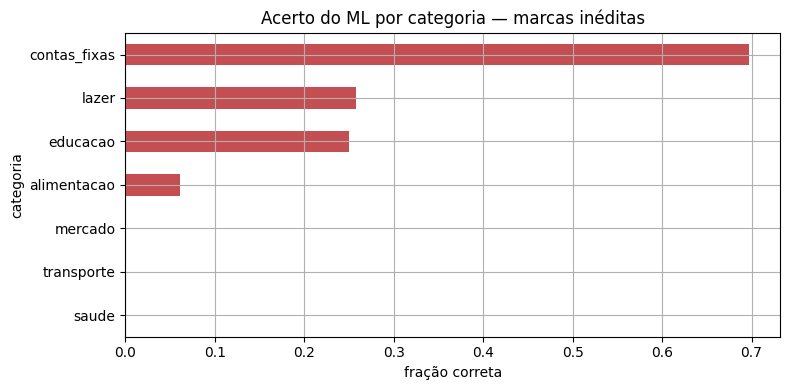

categoria
alimentacao     0.06
contas_fixas    0.70
educacao        0.25
lazer           0.26
mercado         0.00
saude           0.00
transporte      0.00
dtype: float64

In [6]:
# Por que o ML não fica em ZERO como as regras? Sobra um sinal: o VALOR.
novos = lim["df"].copy()
novos["pred_ml"] = lim["pred_ml"]
acerto_cat = (novos["categoria"] == novos["pred_ml"]).groupby(novos["categoria"]).mean()
ax = acerto_cat.sort_values().plot(kind="barh", color="#C44E52")
ax.set_title("Acerto do ML por categoria — marcas inéditas")
ax.set_xlabel("fração correta"); plt.tight_layout(); plt.show()
acerto_cat.round(2)

**Leitura:** o ML fica ~no nível do acaso, mas **não** em zero como as regras — ele
acerta `contas_fixas` (valores altos e característicos) e erra o resto. Ou seja: sem texto,
sobra só o **valor**, que separa categorias caras das baratas e nada mais.

Essa é a **fronteira** da abordagem e o gancho pro trabalho futuro: pra classificar marcas
genuinamente novas seria preciso outro sinal (base de lojistas, embeddings, enriquecimento
externo) — não mais n-grama.

## Resumo

Os três cenários lado a lado contam a história inteira.

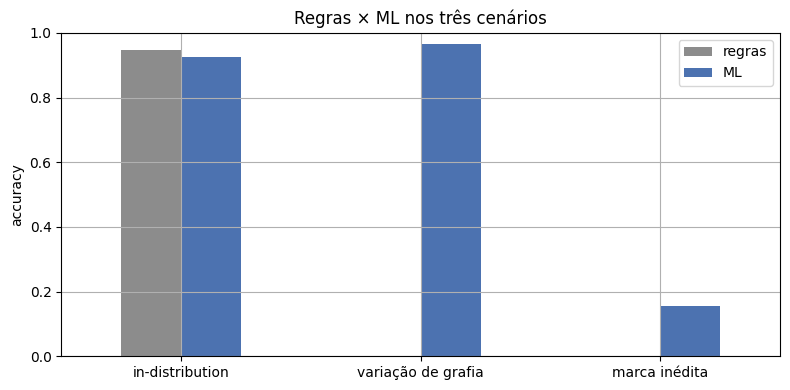

,regras,ML
in-distribution,0.947,0.927
variação de grafia,0.000,0.967
marca inédita,0.000,0.154


In [7]:
resumo = pd.DataFrame(
    {
        "regras": [h["acc_regras"], g["acc_regras"], lim["acc_regras"]],
        "ML": [h["acc_ml"], g["acc_ml"], lim["acc_ml"]],
    },
    index=["in-distribution", "variação de grafia", "marca inédita"],
)
ax = resumo.plot(kind="bar", color=["#8C8C8C", "#4C72B0"])
ax.set_title("Regras × ML nos três cenários")
ax.set_ylabel("accuracy"); ax.set_ylim(0, 1)
plt.xticks(rotation=0); plt.legend(loc="upper right"); plt.tight_layout(); plt.show()
resumo.round(3)

**Conclusão honesta:**
- **In-distribution**, regra e ML empatam — num dado circular, a regra barata basta.
- **Em variação de grafia** (a realidade de um extrato), o ML supera as regras com folga: é
  onde ele se paga.
- **Em marca inédita**, ambos falham; o ML só não zera por causa do valor. É o limite
  declarado da abordagem.

Próximo passo (Etapa 7): ir além da accuracy — precision/recall/f1 por classe, matriz de
confusão e usar `predict_proba` como **confiança por predição** pro app sinalizar
categorizações duvidosas (algo que regra nenhuma entrega).